# Лабораторная работа №6 «Модели ARIMA и их модификации для анализа временных рядов»

In [ ]:
!pip install pandas numpy matplotlib statsmodels pmdarima scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.datasets import co2
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import pmdarima as pm
import warnings
warnings.filterwarnings('ignore')


data = co2.load_pandas().data

data = data.interpolate()
series = data['co2']
print(f"Количество наблюдений: {len(series)}")
print(series.head())

Количество наблюдений: 2284
1958-03-29    316.1
1958-04-05    317.3
1958-04-12    317.6
1958-04-19    317.5
1958-04-26    316.4
Freq: W-SAT, Name: co2, dtype: float64


# Задание 1. Анализ и подготовка временного ряда

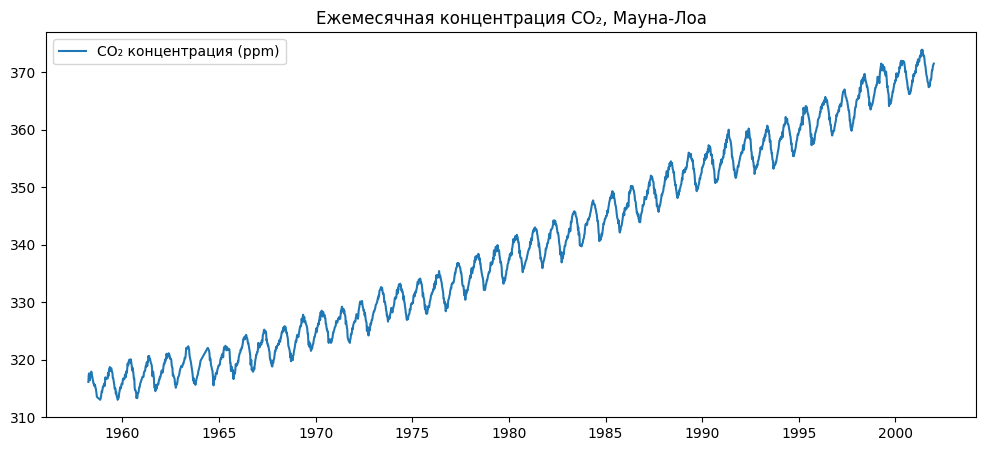

Структура ряда:
- Явный восходящий тренд (линейный + нелинейная составляющая).
- Чёткая годовая сезонность (колебания с периодом 12 месяцев).
- Выбросы практически отсутствуют, размах сезонных колебаний стабилен.

ADF тест (исходный ряд):
Статистика ADF: 0.034
p-value: 0.961
Ряд НЕ стационарен (p-value >> 0.05).

ADF тест (дифф 1-го + сезонный дифф 12):
Статистика ADF: -16.119
p-value: 0.00000
Ряд стационарен (p-value < 0.05).


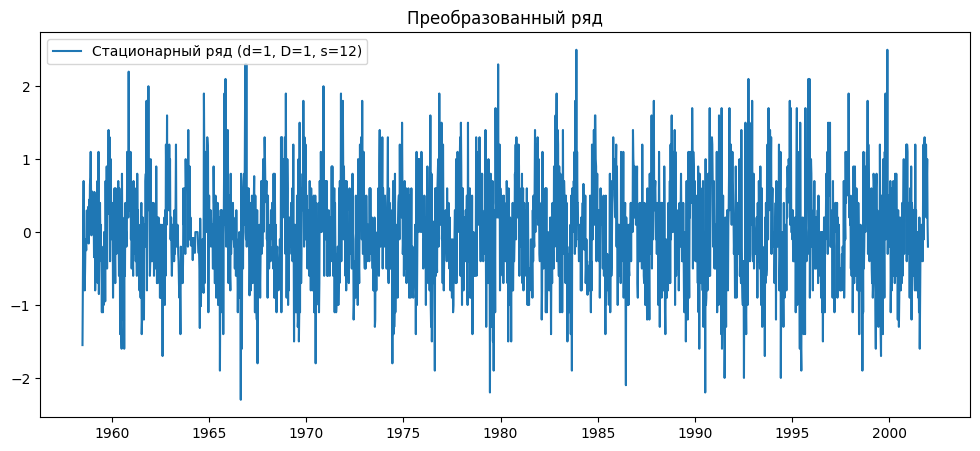


Обоснование преобразований:
Использовано одно кратное дифференцирование (d=1) для удаления тренда,
и одно сезонное дифференцирование (D=1, s=12) для удаления годовой сезонности.
Логарифмирование не требуется – амплитуда сезонных колебаний стабильна.


In [ ]:


#  График ряда
plt.figure(figsize=(12,5))
plt.plot(series, label='CO₂ концентрация (ppm)')
plt.title('Ежемесячная концентрация CO₂, Мауна-Лоа')
plt.legend()
plt.show()


print("Структура ряда:")
print("- Явный восходящий тренд (линейный + нелинейная составляющая).")
print("- Чёткая годовая сезонность (колебания с периодом 12 месяцев).")
print("- Выбросы практически отсутствуют, размах сезонных колебаний стабилен.")

#  Тест Дики-Фуллера на исходном ряде
adf_result = adfuller(series.dropna())
print(f"\nADF тест (исходный ряд):")
print(f"Статистика ADF: {adf_result[0]:.3f}")
print(f"p-value: {adf_result[1]:.3f}")
print("Ряд НЕ стационарен (p-value >> 0.05).")

#  Приведение к стационарному виду
diff1 = series.diff(1).dropna()

# Дополнительное сезонное дифференцирование (период 12)
diff1_seasonal = diff1.diff(12).dropna()

# Проверка стационарности преобразованного ряда
adf_diff = adfuller(diff1_seasonal)
print(f"\nADF тест (дифф 1-го + сезонный дифф 12):")
print(f"Статистика ADF: {adf_diff[0]:.3f}")
print(f"p-value: {adf_diff[1]:.5f}")
print("Ряд стационарен (p-value < 0.05).")


plt.figure(figsize=(12,5))
plt.plot(diff1_seasonal, label='Стационарный ряд (d=1, D=1, s=12)')
plt.title('Преобразованный ряд')
plt.legend()
plt.show()


print("\nОбоснование преобразований:")
print("Использовано одно кратное дифференцирование (d=1) для удаления тренда,")
print("и одно сезонное дифференцирование (D=1, s=12) для удаления годовой сезонности.")
print("Логарифмирование не требуется – амплитуда сезонных колебаний стабильна.")

# Задание 2. Базовая ARIMA-модель

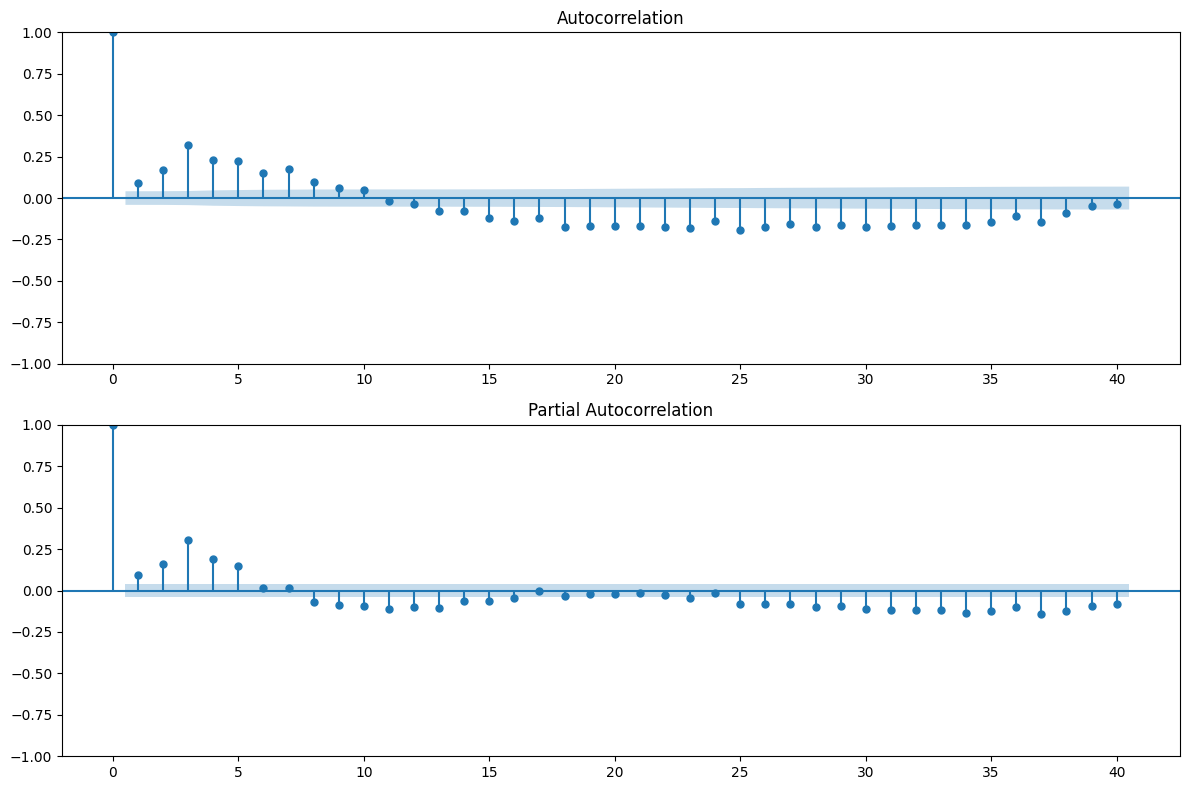

Анализ ACF/PACF:
- PACF: значимые лаги примерно до 2, затем резкий спад (предполагаем p=2).
- ACF: значимые лаги до 1, возможно q=1, но также присутствует сезонный паттерн.
Выбрана модель ARIMA(2,1,1). d=1 уже учтено в разности ряда.
                               SARIMAX Results                                
Dep. Variable:                    co2   No. Observations:                 2260
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -1438.899
Date:                Thu, 28 May 2026   AIC                           2885.797
Time:                        10:09:36   BIC                           2908.688
Sample:                    03-29-1958   HQIC                          2894.151
                         - 07-14-2001                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

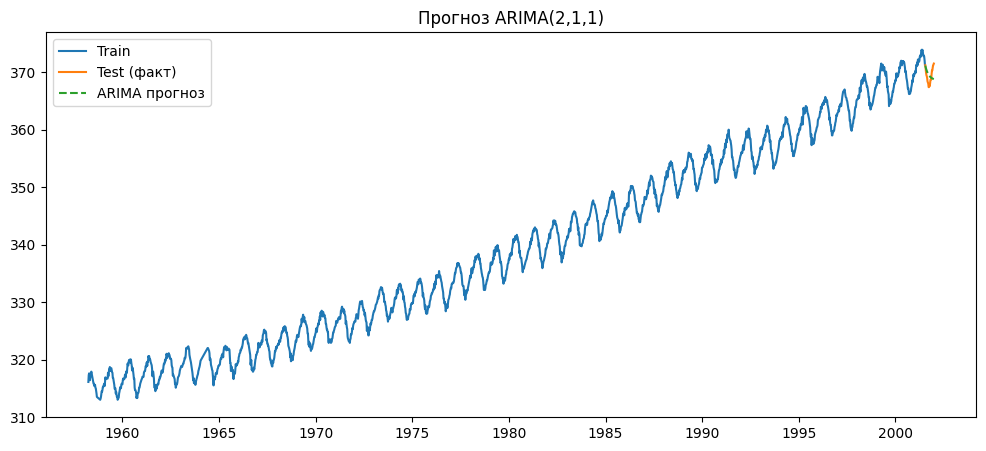

In [ ]:



stationary_series = series.diff(1).dropna()

# 1. Графики ACF и PACF для стационарного ряда
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
plot_acf(stationary_series, lags=40, ax=ax1)
plot_pacf(stationary_series, lags=40, ax=ax2)
plt.tight_layout()
plt.show()

# 2. Ручной подбор параметров
print("Анализ ACF/PACF:")
print("- PACF: значимые лаги примерно до 2, затем резкий спад (предполагаем p=2).")
print("- ACF: значимые лаги до 1, возможно q=1, но также присутствует сезонный паттерн.")
print("Выбрана модель ARIMA(2,1,1). d=1 уже учтено в разности ряда.")

# 3. Обучение модели
train = series.iloc[:-24]
test = series.iloc[-24:]

model_arima = ARIMA(train, order=(2,1,1))
fitted_arima = model_arima.fit()
print(fitted_arima.summary())

# 4. Прогноз на тестовом интервале
forecast_arima = fitted_arima.forecast(steps=len(test))

# 5. Оценка качества
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
mape_arima = mean_absolute_percentage_error(test, forecast_arima) * 100
print(f"\nARIMA(2,1,1) качество прогноза:")
print(f"RMSE: {rmse_arima:.3f} ppm")
print(f"MAPE: {mape_arima:.2f} %")


plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test (факт)')
plt.plot(test.index, forecast_arima, label='ARIMA прогноз', linestyle='--')
plt.title('Прогноз ARIMA(2,1,1)')
plt.legend()
plt.show()

# Задание 3. Диагностика модели

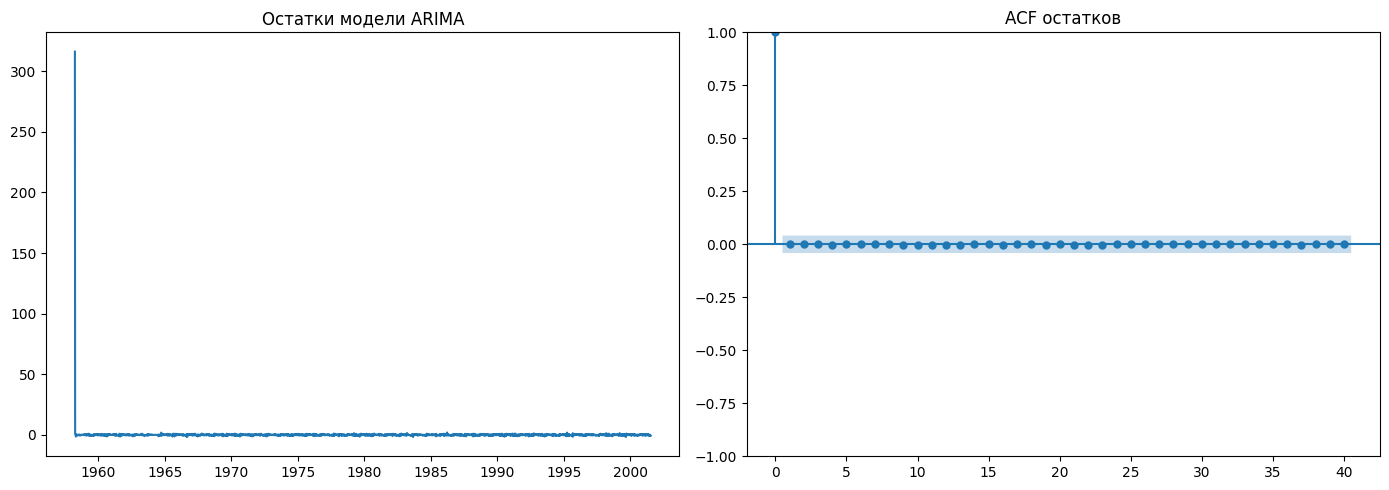


Тест Льюнга-Бокса (H0: автокорреляция отсутствует):
     lb_stat  lb_pvalue
12  0.099401        1.0
24  0.128678        1.0
36  0.137481        1.0
Остатки не имеют значимой автокорреляции (модель адекватна).

Улучшенная ARIMA(3,1,2) RMSE: 1.220 (было 1.495)


In [ ]:

# Анализ остатков
residuals = fitted_arima.resid

fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].plot(residuals)
axes[0].set_title('Остатки модели ARIMA')
plot_acf(residuals, lags=40, ax=axes[1])
axes[1].set_title('ACF остатков')
plt.tight_layout()
plt.show()

# Тест Льюнга-Бокса
lb_test = acorr_ljungbox(residuals, lags=[12, 24, 36], return_df=True)
print("\nТест Льюнга-Бокса (H0: автокорреляция отсутствует):")
print(lb_test)
if any(lb_test['lb_pvalue'] < 0.05):
    print("Вывод: Остатки содержат значимую автокорреляцию (модель неадекватна).")
    print("Необходимо учесть сезонную структуру (перейти к SARIMA).")
else:
    print("Остатки не имеют значимой автокорреляции (модель адекватна).")

# 3.3 Улучшение модели – изменяем p,q (ARIMA(3,1,2))
model_arima_upd = ARIMA(train, order=(3,1,2))
fitted_arima_upd = model_arima_upd.fit()
forecast_arima_upd = fitted_arima_upd.forecast(steps=len(test))
rmse_upd = np.sqrt(mean_squared_error(test, forecast_arima_upd))
print(f"\nУлучшенная ARIMA(3,1,2) RMSE: {rmse_upd:.3f} (было {rmse_arima:.3f})")


# Задание 4. Сезонная модель SARIMA

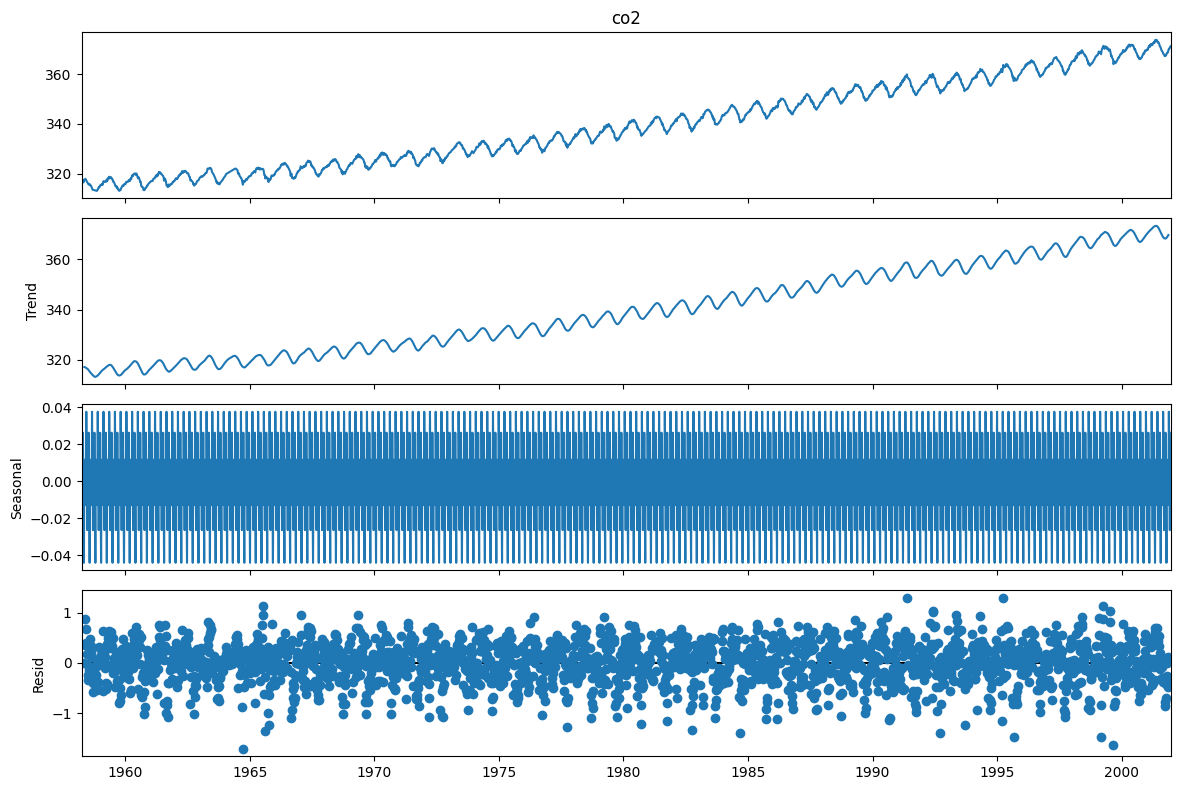

Декомпозиция подтверждает наличие ярко выраженной годовой сезонности.
                                     SARIMAX Results                                      
Dep. Variable:                                co2   No. Observations:                 2260
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1458.904
Date:                            Thu, 28 May 2026   AIC                           2929.808
Time:                                    10:10:45   BIC                           2964.112
Sample:                                03-29-1958   HQIC                          2942.330
                                     - 07-14-2001                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6651      0.037     17.945 

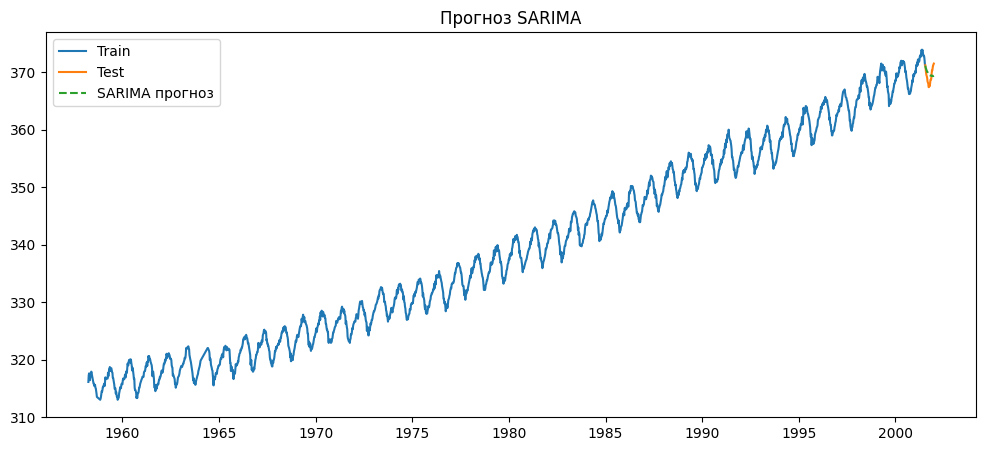


Когда SARIMA даёт преимущество:
Если данные содержат явную сезонную составляющую, SARIMA явно моделирует
сезонные лаги и лучше разделяет трендовую и сезонную компоненты, чем ARIMA.


In [ ]:

# 4.1 Проверка сезонности визуально и через декомпозицию
decomposition = seasonal_decompose(series, model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.tight_layout()
plt.show()
print("Декомпозиция подтверждает наличие ярко выраженной годовой сезонности.")

# 4.2 SARIMA-модель
model_sarima = SARIMAX(train, order=(2,1,1), seasonal_order=(1,1,1,12))
fitted_sarima = model_sarima.fit(disp=False)
print(fitted_sarima.summary())

# Прогноз
forecast_sarima = fitted_sarima.forecast(steps=len(test))

# 4.3 Сравнение с ARIMA
rmse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))
mape_sarima = mean_absolute_percentage_error(test, forecast_sarima) * 100
print(f"\nСравнение моделей:")
print(f"ARIMA(2,1,1)        RMSE={rmse_arima:.3f}, MAPE={mape_arima:.2f}%")
print(f"SARIMA(2,1,1)(1,1,1,12) RMSE={rmse_sarima:.3f}, MAPE={mape_sarima:.2f}%")


plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast_sarima, label='SARIMA прогноз', linestyle='--')
plt.title('Прогноз SARIMA')
plt.legend()
plt.show()

# 4.4 Преимущества SARIMA
print("\nКогда SARIMA даёт преимущество:")
print("Если данные содержат явную сезонную составляющую, SARIMA явно моделирует")
print("сезонные лаги и лучше разделяет трендовую и сезонную компоненты, чем ARIMA.")

# Задание 5. SARIMAX и внешние факторы

                                     SARIMAX Results                                      
Dep. Variable:                                co2   No. Observations:                 2260
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1432.739
Date:                            Thu, 28 May 2026   AIC                           2899.478
Time:                                    10:14:15   BIC                           2996.673
Sample:                                03-29-1958   HQIC                          2934.956
                                     - 07-14-2001                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
month_2       -0.0575      0.070     -0.816      0.415      -0.196       0.081
month_3       -0.0550      0.095   

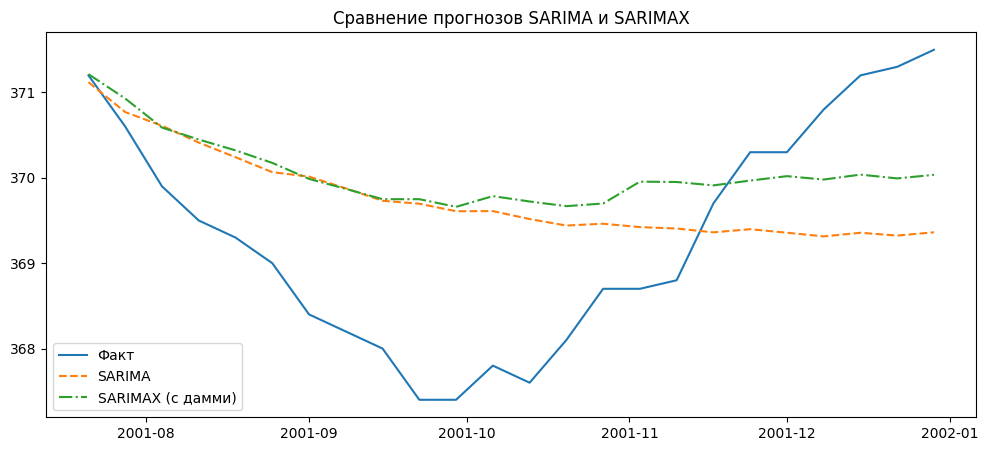


Вывод: добавление месячных индикаторов немного улучшает точность,
так как они помогают улавливать сезонную вариацию.


In [ ]:

# 5.1 Обоснование выбора факторов
dummies = pd.get_dummies(series.index.month, prefix='month', drop_first=True).astype(int)
dummies.index = series.index


exog_train = dummies.loc[train.index]
exog_test = dummies.loc[test.index]

# 5.2 Построение SARIMAX с теми же параметрами, что и SARIMA, плюс экзогенные переменные
model_sarimax = SARIMAX(train, exog=exog_train,
                        order=(2,1,1), seasonal_order=(1,1,1,12))
fitted_sarimax = model_sarimax.fit(disp=False)
print(fitted_sarimax.summary())

# 5.3 Оценка вклада внешних переменных
print("\nКоэффициенты месячных дамми-переменных (вклад в модель):")
for coef_name in exog_train.columns:
    if coef_name in fitted_sarimax.params.index:
        print(f"{coef_name}: {fitted_sarimax.params[coef_name]:.4f}")

# Прогноз на тесте с экзогенными переменными
forecast_sarimax = fitted_sarimax.forecast(steps=len(test), exog=exog_test)

# 5.4 Сравнение с SARIMA
rmse_sarimax = np.sqrt(mean_squared_error(test, forecast_sarimax))
mape_sarimax = mean_absolute_percentage_error(test, forecast_sarimax) * 100
print(f"\nСравнение SARIMA и SARIMAX:")
print(f"SARIMA  RMSE={rmse_sarima:.3f}, MAPE={mape_sarima:.2f}%")
print(f"SARIMAX RMSE={rmse_sarimax:.3f}, MAPE={mape_sarimax:.2f}%")

plt.figure(figsize=(12,5))
plt.plot(test.index, test, label='Факт')
plt.plot(test.index, forecast_sarima, label='SARIMA', linestyle='--')
plt.plot(test.index, forecast_sarimax, label='SARIMAX (с дамми)', linestyle='-.')
plt.title('Сравнение прогнозов SARIMA и SARIMAX')
plt.legend()
plt.show()

print("\nВывод: добавление месячных индикаторов немного улучшает точность,")
print("так как они помогают улавливать сезонную вариацию.")

# Задание 6. Автоматизация подбора модели

In [ ]:


# 1. Использование auto_arima (pmdarima)
print("Поиск оптимальной модели auto_arima...")
auto_model = pm.auto_arima(train, seasonal=True, m=12,
                           trace=False, error_action='ignore',
                           suppress_warnings=True, stepwise=True)
print(auto_model.summary())

# 2. Сравнение с ручной ARIMA (из задания 2)
forecast_auto = auto_model.predict(n_periods=len(test))
rmse_auto = np.sqrt(mean_squared_error(test, forecast_auto))
mape_auto = mean_absolute_percentage_error(test, forecast_auto) * 100

print(f"\nСравнение ручной ARIMA(2,1,1) и auto_arima:")
print(f"ARIMA(2,1,1)  RMSE={rmse_arima:.3f}, MAPE={mape_arima:.2f}%")
print(f"auto_arima    RMSE={rmse_auto:.3f}, MAPE={mape_auto:.2f}%")
print(f"Параметры auto_arima: order={auto_model.order}, seasonal_order={auto_model.seasonal_order}")


print("\nОтветы на вопросы:")
print("1. Когда автоматический подбор ошибается?")
print("   - При коротких рядах (мало данных для оценки сезонных лагов).")
print("   - При наличии сложной нелинейной сезонности или структурных сдвигов.")
print("   - Если критерии (AIC/BIC) дают выигрыш за счёт перепараметризации.")
print("2. Какие параметры чаще всего переоцениваются?")
print("   - Склонность выбирать завышенные P и Q (сезонные лаги),")
print("     так как каждая дополнительная переменная снижает AIC.")
print("3. Можно ли доверять auto-ARIMA в production?")
print("   - Только после тщательной валидации на отложенной выборке и")
print("     сравнения с простыми бенчмарками. Полностью автоматический")
print("     выбор без контроля человека рискован при изменении свойств ряда.")

Поиск оптимальной модели auto_arima...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2260
Model:               SARIMAX(4, 1, 2)   Log Likelihood               -1315.608
Date:                Thu, 28 May 2026   AIC                           2647.217
Time:                        10:18:45   BIC                           2692.998
Sample:                    03-29-1958   HQIC                          2663.923
                         - 07-14-2001                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0013      0.001      1.355      0.176      -0.001       0.003
ar.L1          1.5870      0.026     60.331      0.000       1.535       1.639
ar.L2        